# 1.1 - Claimback 2026 Exploratory Analysis

In [6]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)
pd.set_option("display.float_format", "{:,.2f}".format)

CLEAN_DATA_DIR = Path("outputs") / "cleaned_data"
SUPPORT_CLEANED_FILE = CLEAN_DATA_DIR / "support_cleaned.csv"
GL_ACCOUNTS_CLEANED_FILE = CLEAN_DATA_DIR / "gl_accounts_cleaned.csv"
GL_ENTRIES_CLEANED_FILE = CLEAN_DATA_DIR / "gl_entries_cleaned.csv"

YEAR = 2026
START_DATE = pd.Timestamp(f"{YEAR}-01-01")
SUPPORT_CUTOFF_DATE = pd.Timestamp("2026-06-01")
LEDGER_CUTOFF_DATE = pd.Timestamp("2026-07-01")
EXCLUDED_SUPPLIER_CODES = {"E005GB", "E059"}
REBATE_SUPPLIER_CODE = "U106"
REBATE_PRODUCT_CATEGORY = "PRSCU"


def read_cleaned_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset not found: {path}. Run 0.2 - Data Cleaning first.")
    return pd.read_csv(path, low_memory=False)


def supplier_group_code(code):
    code = "" if pd.isna(code) else str(code).strip()
    if code in {"L810", "L812"}:
        return "L810/L812"
    if code in {"E907", "E907GB"}:
        return "E907/E907GB"
    return code


def supplier_group_name(code, name):
    group = supplier_group_code(code)
    if group == "L810/L812":
        return "Supplier14"
    if group == "E907/E907GB":
        return "Supplier21"
    return "" if pd.isna(name) else str(name).strip()


def extract_supplier_code(description):
    text = "" if pd.isna(description) else str(description).upper()
    matches = re.findall(r"(?<![A-Z0-9])[A-Z]\d{3}(?:GB)?(?![A-Z0-9])", text)
    return supplier_group_code(matches[-1]) if matches else ""


support = read_cleaned_dataset(SUPPORT_CLEANED_FILE)
support["Date"] = pd.to_datetime(support["Date"], errors="coerce", dayfirst=True)
support = support[
    support["Date"].ge(START_DATE)
    & support["Date"].lt(SUPPORT_CUTOFF_DATE)
    & support["SourceTransactionType"].eq("SL/Del")
    & ~support["Contract_Supplier_Code"].isin(EXCLUDED_SUPPLIER_CODES)
].copy()
support["SupplierCode"] = support["Contract_Supplier_Code"].map(supplier_group_code)
support["SupplierName"] = [supplier_group_name(c, n) for c, n in zip(support["Contract_Supplier_Code"], support["Contract_Supplier_Name"])]
support["Quantity"] = pd.to_numeric(support["SalesDeliveryNoteLine_Quantity"], errors="coerce")
support["Quantity"] = support["Quantity"].fillna(pd.to_numeric(support["SalesInvoiceLine_Quantity"], errors="coerce")).fillna(0)
support["UnitClaimAmount"] = pd.to_numeric(support["UnitClaimAmount"], errors="coerce").fillna(0)
support["TotalSupportOwed"] = support["UnitClaimAmount"] * support["Quantity"]
support["Month"] = support["Date"].dt.to_period("M").dt.to_timestamp()
support_2026 = support.copy()

accounts_raw = read_cleaned_dataset(GL_ACCOUNTS_CLEANED_FILE)
entries_raw = read_cleaned_dataset(GL_ENTRIES_CLEANED_FILE)
accounts = pd.DataFrame({
    "GLAccountCode": accounts_raw.get("GL_Account_Code", accounts_raw.get("gl_account_code", accounts_raw.get("Code"))),
    "GLAccountDescription": accounts_raw.get("Description", accounts_raw.get("gl_account_description")),
    "CurrentBalance": pd.to_numeric(accounts_raw.get("Current_Balance", accounts_raw.get("gl_current_balance", accounts_raw.get("CurrentBalance"))), errors="coerce"),
})
entries = pd.DataFrame({
    "GLAccountCode": entries_raw.get("GL_Account_Code", entries_raw.get("gl_account_code")),
    "Description": entries_raw.get("Description", entries_raw.get("gl_account_description")),
    "LedgerDate": pd.to_datetime(entries_raw.get("Entry_Line_Date", entries_raw.get("gl_entry_line_date")), errors="coerce"),
    "CreditAmount": pd.to_numeric(entries_raw.get("Credit_Amount", entries_raw.get("gl_credit_amount")), errors="coerce").fillna(0),
    "RunningBalance": pd.to_numeric(entries_raw.get("Running_Balance"), errors="coerce"),
    "TotalBalance": pd.to_numeric(entries_raw.get("Total_Balance"), errors="coerce"),
})
accounts["SupplierCode"] = accounts["GLAccountDescription"].map(extract_supplier_code)
ledger = entries.merge(accounts[["GLAccountCode", "GLAccountDescription", "SupplierCode"]], on="GLAccountCode", how="left")
missing = ledger["SupplierCode"].isna() | ledger["SupplierCode"].eq("")
ledger.loc[missing, "SupplierCode"] = ledger.loc[missing, "Description"].map(extract_supplier_code)
ledger = ledger[ledger["LedgerDate"].ge(START_DATE) & ledger["LedgerDate"].lt(LEDGER_CUTOFF_DATE)].copy()
ledger["Month"] = ledger["LedgerDate"].dt.to_period("M").dt.to_timestamp()

names = support_2026.groupby("SupplierCode", as_index=False).agg(
    SupplierName=("SupplierName", "first"),
    LinkedSupplierCodes=("Contract_Supplier_Code", lambda s: ", ".join(sorted(set(str(x) for x in s.dropna())))),
)
owed = support_2026.groupby("SupplierCode", as_index=False).agg(
    SupportLines=("Date", "size"),
    ContractCount=("Contract_D_ContractNumber", "nunique"),
    CustomerCount=("Customer", "nunique"),
    ProductCount=("Product", "nunique"),
    TotalSupportOwed=("TotalSupportOwed", "sum"),
)
paid = ledger[ledger["SupplierCode"].ne("")].groupby("SupplierCode", as_index=False).agg(
    LedgerPaid=("CreditAmount", "sum"),
    LedgerLines=("LedgerDate", "size"),
    LatestLedgerDate=("LedgerDate", "max"),
)

supplier_summary = names.merge(owed, on="SupplierCode", how="left").merge(paid, on="SupplierCode", how="left")
supplier_summary["LedgerPaid"] = supplier_summary["LedgerPaid"].fillna(0)
supplier_summary["LedgerLines"] = supplier_summary["LedgerLines"].fillna(0)
supplier_summary["Outstanding"] = supplier_summary["TotalSupportOwed"] - supplier_summary["LedgerPaid"]
supplier_summary["PaidPct"] = supplier_summary["LedgerPaid"].div(supplier_summary["TotalSupportOwed"]).where(supplier_summary["TotalSupportOwed"].ne(0), 0)
supplier_summary["SupportOwed"] = supplier_summary["TotalSupportOwed"]
supplier_summary["PaidPercent"] = supplier_summary["PaidPct"] * 100
supplier_summary = supplier_summary.sort_values("Outstanding", ascending=False)

ledger_month = ledger.groupby("Month", as_index=False).agg(LedgerPaid=("CreditAmount", "sum"))
monthly_summary = support_2026.groupby("Month", as_index=False).agg(TotalSupportOwed=("TotalSupportOwed", "sum")).merge(ledger_month, on="Month", how="outer").fillna(0).sort_values("Month")
monthly_summary["OutstandingMovement"] = monthly_summary["TotalSupportOwed"] - monthly_summary["LedgerPaid"]

rebate_mask = support_2026["SupplierCode"].eq(REBATE_SUPPLIER_CODE) & support_2026["Product_Category"].astype("string").str.upper().eq(REBATE_PRODUCT_CATEGORY)
rebate_adjustment = pd.DataFrame([{
    "SupplierCode": REBATE_SUPPLIER_CODE,
    "SupplierName": "Supplier1",
    "ProductCategoryShownSeparately": REBATE_PRODUCT_CATEGORY,
    "SupportLines": int(rebate_mask.sum()),
    "SupportValue": float(support_2026.loc[rebate_mask, "TotalSupportOwed"].sum()),
}])
supplier_summary_adjusted = supplier_summary.copy()
adjusted_index = supplier_summary_adjusted["SupplierCode"].eq(REBATE_SUPPLIER_CODE)
supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"] = supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"] - rebate_adjustment.loc[0, "SupportValue"]
supplier_summary_adjusted.loc[adjusted_index, "SupportOwed"] = supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"]
supplier_summary_adjusted.loc[adjusted_index, "Outstanding"] = supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"] - supplier_summary_adjusted.loc[adjusted_index, "LedgerPaid"]
supplier_summary_adjusted.loc[adjusted_index, "PaidPct"] = supplier_summary_adjusted.loc[adjusted_index, "LedgerPaid"].div(supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"]).where(supplier_summary_adjusted.loc[adjusted_index, "TotalSupportOwed"].ne(0), 0)
supplier_summary_adjusted["PaidPercent"] = supplier_summary_adjusted["PaidPct"] * 100
supplier_summary_adjusted = supplier_summary_adjusted.sort_values("Outstanding", ascending=False)

total_support_owed = supplier_summary["TotalSupportOwed"].sum()
total_ledger_paid = supplier_summary["LedgerPaid"].sum()
total_outstanding = supplier_summary["Outstanding"].sum()
total_outstanding_adjusted = supplier_summary_adjusted["Outstanding"].sum()

print("Support rows in report window:", support_2026.shape, "Ledger rows:", ledger.shape)
display(supplier_summary.head(10))
display(monthly_summary)
display(rebate_adjustment)


Support rows in report window: (11848, 61) Ledger rows: (115, 9)


,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalSupportOwed,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct,SupportOwed,PaidPercent
2,E070,Supplier19,E070,410,11,12,123,"105,767.42","9,124.28",4.00,2026-04-20,"96,643.14",0.09,"105,767.42",8.63
3,E071,Supplier13,E071,617,28,102,21,"229,976.83","149,850.93",64.00,2026-06-22,"80,125.90",0.65,"229,976.83",65.16
17,U102,Supplier4,U102,173,6,57,16,"60,509.64",0.00,0.00,NaT,"60,509.64",0.00,"60,509.64",0.00
18,U106,Supplier1,U106,6645,93,170,190,"36,316.55","3,744.41",1.00,2026-02-23,"32,572.14",0.10,"36,316.55",10.31
10,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,"33,022.00","15,486.00",7.00,2026-05-14,"17,536.00",0.47,"33,022.00",46.90
4,E102,Supplier7,E102,274,2,103,14,"6,618.42",0.00,0.00,NaT,"6,618.42",0.00,"6,618.42",0.00
9,E631,Supplier16,E631,69,3,3,29,"1,210.53",0.00,0.00,NaT,"1,210.53",0.00,"1,210.53",0.00
13,L810/L812,Supplier14,"L810, L812",853,0,15,139,"6,865.41","5,811.16",4.00,2026-06-29,"1,054.25",0.85,"6,865.41",84.64
7,E269A,Supplier17,E269A,55,0,28,4,586.00,0.00,0.00,NaT,586.00,0.00,586.00,0.00
16,N023,Supplier22,N023,370,9,8,89,838.75,276.94,3.00,2026-06-22,561.81,0.33,838.75,33.02


,Month,TotalSupportOwed,LedgerPaid,OutstandingMovement
0,2026-01-01,"102,658.79",0.00,"102,658.79"
1,2026-02-01,"98,972.78","21,596.54","77,376.24"
2,2026-03-01,"133,632.25","12,509.06","121,123.19"
3,2026-04-01,"91,130.81","28,926.66","62,204.15"
4,2026-05-01,"110,706.96","108,502.15","2,204.81"
5,2026-06-01,0.00,"81,549.19","-81,549.19"


,SupplierCode,SupplierName,ProductCategoryShownSeparately,SupportLines,SupportValue
0,U106,Supplier1,PRSCU,6538,"30,690.17"


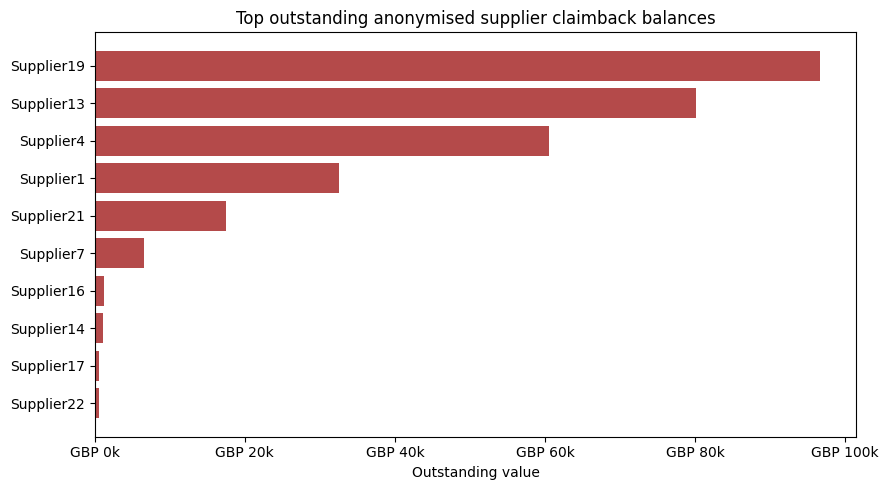

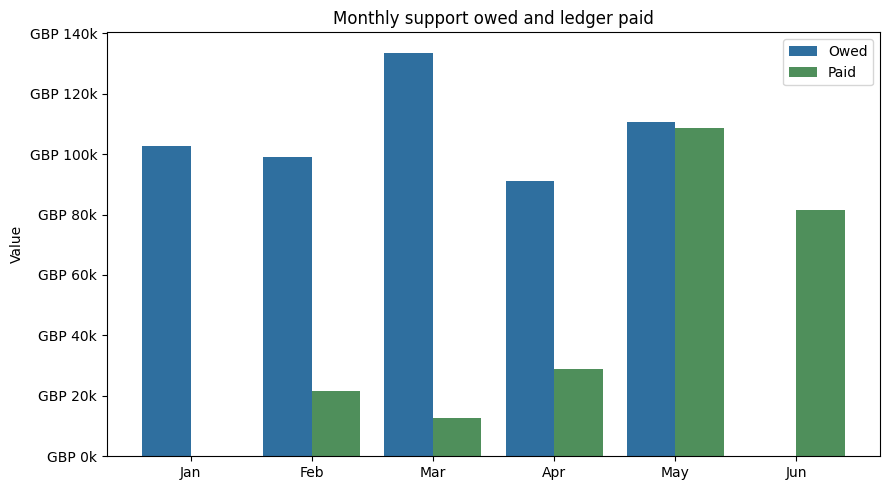

In [7]:
top=supplier_summary[supplier_summary["Outstanding"].gt(0)].head(10).sort_values("Outstanding")
fig,ax=plt.subplots(figsize=(9,5)); ax.barh(top["SupplierName"],top["Outstanding"],color="#b44a4a"); ax.set_title("Top outstanding anonymised supplier claimback balances"); ax.set_xlabel("Outstanding value"); ax.xaxis.set_major_formatter(lambda x,pos:f"GBP {x/1000:,.0f}k"); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(9,5)); x=range(len(monthly_summary)); ax.bar([i-.2 for i in x],monthly_summary["TotalSupportOwed"],width=.4,label="Owed",color="#2f6f9f"); ax.bar([i+.2 for i in x],monthly_summary["LedgerPaid"],width=.4,label="Paid",color="#4f8f5b"); ax.set_xticks(list(x),[d.strftime("%b") if hasattr(d,"strftime") else str(d) for d in monthly_summary["Month"]]); ax.set_title("Monthly support owed and ledger paid"); ax.set_ylabel("Value"); ax.legend(); ax.yaxis.set_major_formatter(lambda y,pos:f"GBP {y/1000:,.0f}k"); plt.tight_layout(); plt.show()


In [8]:
explore = supplier_summary.copy()
money_cols = [col for col in ["SupportOwed", "TrackerPaid", "LedgerPaid", "Paid", "Outstanding"] if col in explore.columns]
for col in money_cols:
    explore[col] = pd.to_numeric(explore[col], errors="coerce").fillna(0)

if "PaidPercent" not in explore.columns:
    paid_col = "LedgerPaid" if "LedgerPaid" in explore.columns else ("TrackerPaid" if "TrackerPaid" in explore.columns else "Paid")
    owed_col = "SupportOwed" if "SupportOwed" in explore.columns else "Owed"
    if paid_col in explore.columns and owed_col in explore.columns:
        explore["PaidPercent"] = np.where(explore[owed_col].gt(0), explore[paid_col] / explore[owed_col] * 100, 0)

sort_col = "Outstanding" if "Outstanding" in explore.columns else money_cols[-1]

display(explore.sort_values(sort_col, ascending=False).head(10))

,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalSupportOwed,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct,SupportOwed,PaidPercent
2,E070,Supplier19,E070,410,11,12,123,"105,767.42","9,124.28",4.00,2026-04-20,"96,643.14",0.09,"105,767.42",8.63
3,E071,Supplier13,E071,617,28,102,21,"229,976.83","149,850.93",64.00,2026-06-22,"80,125.90",0.65,"229,976.83",65.16
17,U102,Supplier4,U102,173,6,57,16,"60,509.64",0.00,0.00,NaT,"60,509.64",0.00,"60,509.64",0.00
18,U106,Supplier1,U106,6645,93,170,190,"36,316.55","3,744.41",1.00,2026-02-23,"32,572.14",0.10,"36,316.55",10.31
10,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,"33,022.00","15,486.00",7.00,2026-05-14,"17,536.00",0.47,"33,022.00",46.90
4,E102,Supplier7,E102,274,2,103,14,"6,618.42",0.00,0.00,NaT,"6,618.42",0.00,"6,618.42",0.00
9,E631,Supplier16,E631,69,3,3,29,"1,210.53",0.00,0.00,NaT,"1,210.53",0.00,"1,210.53",0.00
13,L810/L812,Supplier14,"L810, L812",853,0,15,139,"6,865.41","5,811.16",4.00,2026-06-29,"1,054.25",0.85,"6,865.41",84.64
7,E269A,Supplier17,E269A,55,0,28,4,586.00,0.00,0.00,NaT,586.00,0.00,586.00,0.00
16,N023,Supplier22,N023,370,9,8,89,838.75,276.94,3.00,2026-06-22,561.81,0.33,838.75,33.02


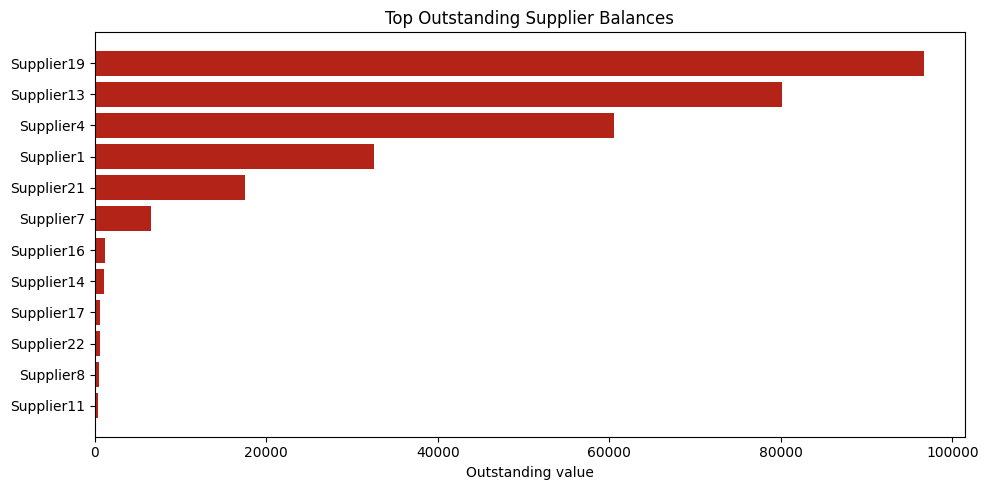

In [9]:
if "Outstanding" in explore.columns:
    top = explore[explore["Outstanding"].gt(0)].sort_values("Outstanding", ascending=False).head(12)
    plt.figure(figsize=(10, 5))
    plt.barh(top.iloc[::-1]["SupplierName"], top.iloc[::-1]["Outstanding"], color="#b42318")
    plt.title("Top Outstanding Supplier Balances")
    plt.xlabel("Outstanding value")
    plt.tight_layout()
    plt.show()

Monthly claimback movement


,Month,TotalSupportOwed,LedgerPaid,OutstandingMovement
0,2026-01-01,"102,658.79",0.00,"102,658.79"
1,2026-02-01,"98,972.78","21,596.54","77,376.24"
2,2026-03-01,"133,632.25","12,509.06","121,123.19"
3,2026-04-01,"91,130.81","28,926.66","62,204.15"
4,2026-05-01,"110,706.96","108,502.15","2,204.81"
5,2026-06-01,0.00,"81,549.19","-81,549.19"


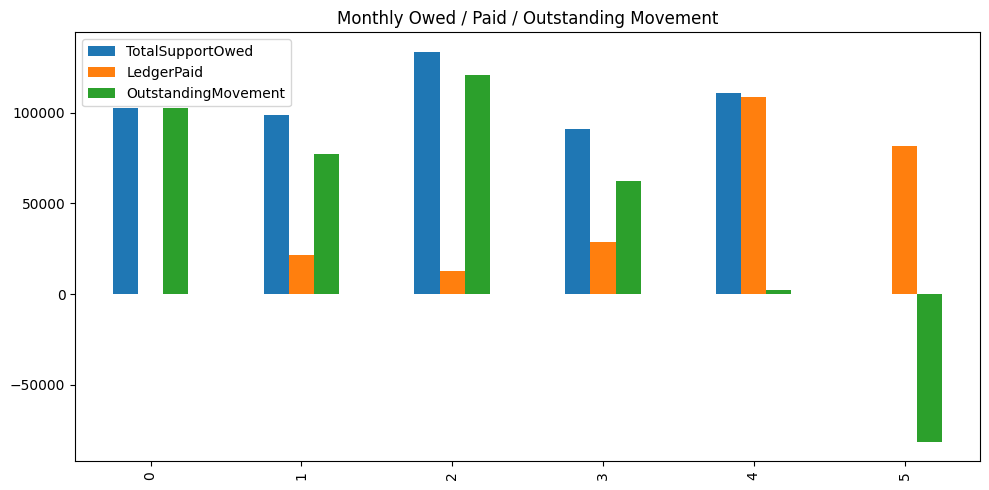

In [10]:
if "monthly_summary" in globals():
    month_view = monthly_summary.copy()
    print("Monthly claimback movement")
    display(month_view)
    numeric = month_view.select_dtypes(include=[np.number])
    if not numeric.empty:
        numeric.plot(kind="bar", figsize=(10, 5), title="Monthly Owed / Paid / Outstanding Movement")
        plt.tight_layout()
        plt.show()